<a href="https://colab.research.google.com/github/stoprider/AI-Adventure-Academy/blob/main/%E0%B9%82%E0%B8%84%E0%B8%A3%E0%B8%87%E0%B8%81%E0%B8%B2%E0%B8%A3_Isan_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🚀 เริ่มต้นโครงการ Isan AI (Phase 1: Environment Setup & Directory Structure)
ขั้นตอนนี้จะเป็นการเตรียมความพร้อมสำหรับการทำระบบแปลภาษาและการประมวลผลคำภาษาอีสาน โดยจะทำการสร้างโฟลเดอร์สำหรับจัดเก็บชุดข้อมูลโมเดล และทดสอบโหลดไลบรารีที่จำเป็น

In [1]:
import os
import pandas as pd
import json

# 1. สร้างโครงสร้างโฟลเดอร์เริ่มต้นสำหรับโครงการ Isan AI
project_dirs = [
    'isan-ai/dataset',
    'isan-ai/models',
    'isan-ai/training',
    'isan-ai/evaluation'
]

for directory in project_dirs:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")
    else:
        print(f"Directory already exists: {directory}")

# 2. จำลองตัวอย่างข้อมูลภาษาอีสานเป็นไฟล์ JSONL (ตามรูปแบบในแผนโครงการ)
sample_data = [
    {"isan": "มื้อนี้เจ้าสิไปไส", "thai": "วันนี้คุณจะไปไหน", "intent": "ask_destination"},
    {"isan": "ข้อยกำลังไปตลาด", "thai": "ฉันกำลังไปตลาด", "intent": "going_to_place"},
    {"isan": "กินข้าวแล้วบ่", "thai": "กินข้าวหรือยัง", "intent": "ask_eating"},
    {"isan": "กะโอเคอยู่เด้อ", "thai": "ก็โอเคอยู่นะ", "intent": "feeling_ok"}
]

dataset_path = 'isan-ai/dataset/sample_isan_thai.jsonl'
with open(dataset_path, 'w', encoding='utf-8') as f:
    for entry in sample_data:
        f.write(json.dumps(entry, ensure_ascii=False) + '\n')

print(f"\nSaved sample dataset to: {dataset_path}")

# 3. ทดลองอ่านไฟล์เพื่อตรวจสอบความถูกต้อง
df_sample = pd.read_json(dataset_path, lines=True)
display(df_sample)

Created directory: isan-ai/dataset
Created directory: isan-ai/models
Created directory: isan-ai/training
Created directory: isan-ai/evaluation

Saved sample dataset to: isan-ai/dataset/sample_isan_thai.jsonl


,isan,thai,intent
0,มื้อนี้เจ้าสิไปไส,วันนี้คุณจะไปไหน,ask_destination
1,ข้อยกำลังไปตลาด,ฉันกำลังไปตลาด,going_to_place
2,กินข้าวแล้วบ่,กินข้าวหรือยัง,ask_eating
3,กะโอเคอยู่เด้อ,ก็โอเคอยู่นะ,feeling_ok


### 📊 การโหลด Dataset ภาษาอีสานจาก Hugging Face
เราจะใช้ไลบรารี `datasets` เพื่อทำการดึงข้อมูลเสียงและคำแปลภาษาอีสาน เช่น ชุดข้อมูลของโครงการ VISTEC (Typhoon Isan ASR) หรือสถาบันวิจัยอื่น ๆ มาใช้งานศึกษาในเบื้องต้น

In [2]:
!pip install -q datasets soundfile librosa

In [5]:
from huggingface_hub import HfApi
from datasets import load_dataset
import pandas as pd

# กำหนดเป้าหมายชุดข้อมูลที่เป็นภาษาอีสาน (Isan) ของไทยโดยตรง
priority_datasets = [
    'pythainlp/isan_dict',
    'typhoon-ai/thai-dialect-isan-dataset',
    'Isan4056/isan-dataset',
    'typhoon-ai/isan-phonetic-dictionary'
]

target_dataset = None

print("🔍 เริ่มตรวจสอบและดาวน์โหลดชุดข้อมูลอีสานจาก Hugging Face...")

# ทดลองโหลดตามลำดับความเหมาะสมของข้อมูล
for ds_name in priority_datasets:
    try:
        print(f"⏳ กำลังพยายามดาวน์โหลด: '{ds_name}'...")
        dataset = load_dataset(ds_name, split="train")
        df_hf = pd.DataFrame(dataset)
        target_dataset = ds_name
        print(f"✅ ดาวน์โหลดสำเร็จจาก: '{ds_name}'! จำนวนทั้งหมด: {len(df_hf)} แถว")
        break
    except Exception as e:
        print(f"⚠️ ไม่สามารถโหลด '{ds_name}' ได้: {e}\n")

if target_dataset and 'df_hf' in locals():
    # แสดงข้อมูลตัวอย่าง
    display(df_hf.head(10))

    # บันทึกไฟล์ลงในโฟลเดอร์โครงการ
    hf_save_path = 'isan-ai/dataset/hf_isan_downloaded.csv'
    df_hf.to_csv(hf_save_path, index=False, encoding='utf-8')
    print(f"\n💾 บันทึกข้อมูลสำเร็จที่: {hf_save_path}")
else:
    print("❌ ไม่สามารถดาวน์โหลดชุดข้อมูลจากรายการหลักได้ ระบบกำลังใช้ข้อมูลสำรองแบบจำลอง")

🔍 เริ่มตรวจสอบและดาวน์โหลดชุดข้อมูลอีสานจาก Hugging Face...
⏳ กำลังพยายามดาวน์โหลด: 'pythainlp/isan_dict'...


README.md:   0%|          | 0.00/794 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  424kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2139 [00:00<?, ? examples/s]

✅ ดาวน์โหลดสำเร็จจาก: 'pythainlp/isan_dict'! จำนวนทั้งหมด: 2139 แถว


,word,meaning,province,sentence_example
0,ปลาเซือม,ปลาเนื้ออ่อน,อุดรธานี,[]
1,แฉ่ง,ฉาบใหญ่,มุกดาหาร,"[{'sentence': 'เอาแฉ่งมาให้แหน่', 'translated'..."
2,มุ่นอุ้ยปุ้ย,มั่วไปหมด/เละเทะหมด/ไม่เป็นชิ้นเป็นอัน,ขอนแก่น,[{'sentence': 'อ้ายมังกายเดียวดอนจ่มให่อ้ายหน่...
3,ฮักแพง,รักมาก/หวงมาก/อันเป็นที่รักยิ่ง,มุกดาหาร,"[{'sentence': 'อ้ายฮักแพงเจ้าหลาย', 'translate..."
4,นัว,การอร่อยที่ลงตัวที่สุด,ร้อยเอ็ด,[{'sentence': 'แนวกิน(กับข้าว) มื้อนี้มาคือแซ...
5,ก้านจอง,ทับพี,สกลนคร,[]
6,ต้อม,รวมกันเข้า/เอามารวมกัน,ร้อยเอ็ด,[{'sentence': 'พ่อใหญ่ดล กับพ่อใหญ่บัติ สองเฒ...
7,ฮาก,อาเจียน/รากไม้,ร้อยเอ็ด,[{'sentence': 'เห็นหน้าบ่าวหนอแล้ว สิฮากหวะ ...
8,ตาง,แทน/ทดแทน,ร้อยเอ็ด,"[{'sentence': 'อดสาแง้นกินลิงตางกะต่าย', 'tran..."
9,อิหยัง,อะไร,ร้อยเอ็ด,"[{'sentence': 'โตเป็นอิหยัง', 'translated': 'แ..."



💾 บันทึกข้อมูลสำเร็จที่: isan-ai/dataset/hf_isan_downloaded.csv


### 📊 วิเคราะห์และสรุปแหล่งที่มาของคำศัพท์ในพจนานุกรมภาษาอีสาน (df_hf)
เราจะทำการนับความถี่ของข้อมูลในคอลัมน์ `province` เพื่อสรุปว่าคำศัพท์ส่วนใหญ่มีที่มาจากจังหวัดใดบ้างในภาคอีสาน

ลงทะเบียนฟอนต์สำเร็จ: Sarabun
=== ตารางสรุปจำนวนคำศัพท์แยกตามจังหวัด ===


,Province,Word Count
0,มุกดาหาร,460
1,ร้อยเอ็ด,363
2,ขอนแก่น,168
3,มหาสารคาม,154
4,หนองคาย,149
5,บุรีรัมย์,149
6,สกลนคร,101
7,อุดรธานี,74
8,กาฬสินธุ์,70
9,อุบลราชธานี,56


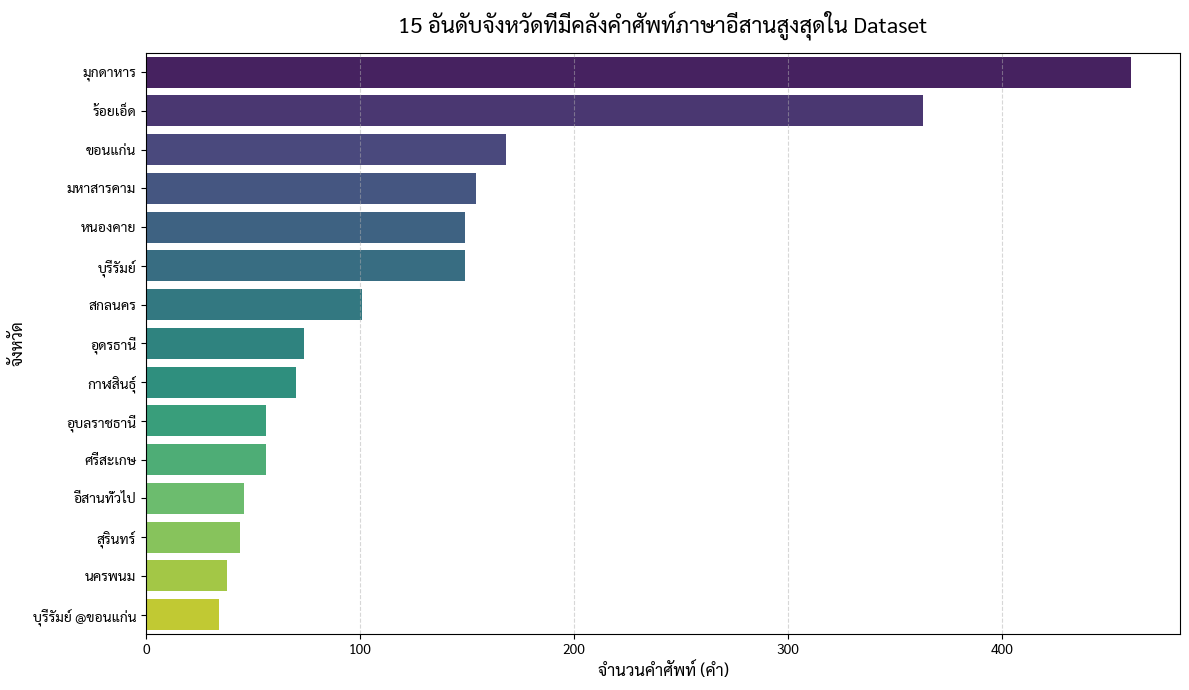

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.font_manager as fm

# ลงทะเบียนฟอนต์ Sarabun-Regular.ttf เข้าสู่ Matplotlib โดยตรง
font_path = '/usr/share/fonts/truetype/Sarabun-Regular.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    mpl.rcParams['font.family'] = prop.get_name()
    print(f"ลงทะเบียนฟอนต์สำเร็จ: {prop.get_name()}")
else:
    print("ไม่พบไฟล์ฟอนต์กรุณาตรวจสอบการติดตั้งฟอนต์ภาษาไทยในเซลล์ถัดไป")

mpl.rcParams['axes.unicode_minus'] = False

# 1. จัดเตรียมข้อมูลนับจำนวนคำศัพท์แยกตามจังหวัด
province_counts = df_hf['province'].fillna('ไม่ระบุจังหวัด').value_counts().reset_index()
province_counts.columns = ['Province', 'Word Count']

# แสดงผลลัพธ์ในรูปแบบตาราง
print("=== ตารางสรุปจำนวนคำศัพท์แยกตามจังหวัด ===")
display(province_counts.head(15))

# 2. แสดงผลในรูปแบบกราฟแท่ง (Bar Chart)
plt.figure(figsize=(12, 7))
sns.barplot(x='Word Count', y='Province', data=province_counts.head(15), palette='viridis', hue='Province', legend=False)

# ตั้งค่าฟอนต์และการแสดงผลภาษาไทย
plt.title('15 อันดับจังหวัดที่มีคลังคำศัพท์ภาษาอีสานสูงสุดใน Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('จำนวนคำศัพท์ (คำ)', fontsize=12)
plt.ylabel('จังหวัด', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 🎲 ระบบแนะนำคำศัพท์ภาษาอีสานแบบสุ่ม (Isan Random Vocabulary Recommender)
ส่วนนี้เป็นฟังก์ชันสำหรับสุ่มคำศัพท์ภาษาอีสานจากฐานข้อมูลที่เราดาวน์โหลดมาจาก Hugging Face เพื่อช่วยฝึกฝนและเรียนรู้คำศัพท์ถิ่นต่างๆ พร้อมทั้งแสดงคำแปลและแหล่งที่มาของจังหวัด

In [10]:
import random
from IPython.display import display, HTML

def get_random_isan_word(df):
    """
    ฟังก์ชันสำหรับสุ่มคำศัพท์ภาษาอีสานจาก DataFrame
    """
    if df is None or df.empty:
        return "ไม่พบข้อมูลคำศัพท์ในฐานข้อมูล"

    # สุ่มข้อมูลมา 1 แถว
    random_row = df.sample(n=1).iloc[0]

    word = random_row.get('word', 'ไม่ทราบคำศัพท์')
    meaning = random_row.get('meaning', 'ไม่ทราบความหมาย')
    province = random_row.get('province', 'ไม่ระบุจังหวัด')

    # หากคอลัมน์ province ว่างเปล่า ให้แสดงว่าไม่ระบุจังหวัด
    if pd.isna(province) or str(province).strip() == "":
        province = "ไม่ระบุจังหวัด"

    # จัดแต่งหน้าต่างแสดงผลด้วย HTML/CSS
    html_card = f"""
    <div style="
        border: 2px solid #4CAF50;
        border-radius: 12px;
        padding: 20px;
        background-color: #f9f9f9;
        max-width: 500px;
        font-family: 'Sarabun', sans-serif;
        box-shadow: 0 4px 8px rgba(0,0,0,0.1);
        margin: 15px 0;
    ">
        <span style="
            background-color: #4CAF50;
            color: white;
            padding: 4px 10px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: bold;
        ">คำศัพท์อีสานวันนี้</span>

        <h2 style="color: #2e7d32; margin-top: 15px; margin-bottom: 5px; font-size: 28px;">{word}</h2>
        <p style="color: #666; font-size: 14px; margin-top: 0; margin-bottom: 15px;">
            📍 <b>สำเนียง/แหล่งที่มา:</b> จังหวัด {province}
        </p>

        <hr style="border: 0; border-top: 1px solid #ddd; margin: 15px 0;">

        <p style="font-size: 18px; color: #333; line-height: 1.6;">
            <b>ความหมาย:</b> {meaning}
        </p>
    </div>
    """
    display(HTML(html_card))

# รันฟังก์ชันสุ่มคำศัพท์
get_random_isan_word(df_hf)

### 💬 Isan AI Chat Bot Simulator (UI จำลองการสนทนาภาษาอีสาน)
ส่วนนี้เป็นการสร้างหน้าต่างแชทจำลองที่ให้คุณสามารถพิมพ์โต้ตอบเป็นภาษาอีสานหรือภาษาไทยกลางกับน้อง AI ได้ โดยบอทจะเลือกคำตอบที่เหมาะสมจากคลังความรู้พร้อมระบบแสดงคำแปลภาษาไทยกลางให้ทันที

In [13]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd

# 1. ขยายคลังข้อมูลประโยคสนทนาในชีวิตประจำวันให้รอบด้านและเป็นธรรมชาติยิ่งขึ้น
knowledge_base = [
    {
        "keywords": ["สวัสดี", "สบายดีบ่", "เป็นจั่งได๋", "จั่งได๋", "หวัดดี", "สบายดี"],
        "isan_reply": "สบายดีจ้า มื้อนี้มีหยังให้น้องช่วยบ่เด้อ? เจ้าสบายดีบ่?",
        "thai_reply": "สบายดีค่ะ วันนี้มีอะไรให้ฉันช่วยไหมคะ? คุณสบายดีไหมคะ?"
    },
    {
        "keywords": ["กินข้าว", "กินหยัง", "กินข้าวแล้วบ่", "หาแนวอ้าง", "หิว"],
        "isan_reply": "กินแล้วเด้อ แซบคัก! เจ้าเด้กินข้าวกับหยังล่ะ? ส้มตำบ่น้อ?",
        "thai_reply": "กินแล้วค่ะ อร่อยมาก! คุณล่ะกินข้าวกับอะไรคะ? ส้มตำหรือเปล่านะ?"
    },
    {
        "keywords": ["ไปไส", "ไปเที่ยว", "ไปทำงาน", "ไปทางได๋", "ทำอะไร"],
        "isan_reply": "ข้อยกำลังสิไปเที่ยวเล่นแถวนี้ล่ะ เจ้าอยากไปนำกันบ่?",
        "thai_reply": "ฉันกำลังจะไปเที่ยวเล่นแถวนี้ค่ะ คุณอยากไปด้วยกันไหม?"
    },
    {
        "keywords": ["ขอบคุณ", "ขอบใจ", "ใจจ้า"],
        "isan_reply": "ยินดีคัก ๆ จ้า มีหยังให้รับใช้บอกได้เลยเด้อ",
        "thai_reply": "ยินดีมากๆ ค่ะ มีอะไรให้รับใช้บอกได้เลยนะคะ"
    },
    {
        "keywords": ["รัก", "ฮัก", "ชอบ"],
        "isan_reply": "ฮักแพงคือกันเด้อจ้า ขอให้มื้อนี้เป็นมื้อที่ดีของเจ้า!",
        "thai_reply": "รักเหมือนกันนะคะ ขอให้วันนี้เป็นวันที่ดีของคุณ!"
    },
    {
        "keywords": ["ชื่ออะไร", "ชื่อหยัง", "เป็นใคร", "ซื่อหยัง"],
        "isan_reply": "น้องซื่อ 'Isan AI' เป็นบอทน้อยคนอีสานบ้านเฮานี่ล่ะจ้า!",
        "thai_reply": "ฉันชื่อ 'Isan AI' เป็นบอทคนอีสานบ้านเรานี่แหละค่ะ!"
    },
    {
        "keywords": ["ทำอะไรอยู่", "เฮ็ดหยัง", "ทำไร"],
        "isan_reply": "กำลังนั่งคอยคุยนำเจ้าอยู่ นี่ล่ะจ้า มีเรื่องหยังคุยสู่ฟังบ่?",
        "thai_reply": "กำลังนั่งรอคุยกับคุณอยู่เลยค่ะ มีเรื่องอะไรเล่าให้ฟังไหมคะ?"
    },
    {
        "keywords": ["เหนื่อย", "เมื่อย", "ท้อ"],
        "isan_reply": "สู้ ๆ เด้อเจ้า! อย่าเพิ่งฟ้าวเมื่อยล้า นั่งพักกินน้ำเย็น ๆ ก่อนนะ",
        "thai_reply": "สู้ ๆ นะคะ! อย่าเพิ่งรีบเหนื่อยล้า นั่งพักดื่มน้ำเย็น ๆ ก่อนนะ"
    },
    {
        "keywords": ["ร้อน", "ฮ้อน"],
        "isan_reply": "โอ๊ย! มื้อนี้ฮ้อนคักฮ้อนแน่ ร้อนจนสิละลายแล้วเด้อ!",
        "thai_reply": "โอ๊ย! วันนี้ร้อนมาก ๆ ร้อนจนจะละลายแล้วค่ะ!"
    }
]

def get_chatbot_response(user_text):
    user_text = user_text.lower().strip()

    # 1. เช็กการแมตช์ตามบทสนทนาทั่วไป (Conversational Chat)
    for item in knowledge_base:
        if any(keyword in user_text for keyword in item["keywords"]):
            return item["isan_reply"], item["thai_reply"]

    # 2. เช็กคำศัพท์เดี่ยวในพจนานุกรมเพื่อตอบ (Dictionary Lookup)
    if 'df_hf' in globals() and not df_hf.empty:
        matched_rows = df_hf[df_hf['word'].str.contains(user_text, na=False, case=False)]
        if not matched_rows.empty:
            row = matched_rows.iloc[0]
            word = row['word']
            meaning = row['meaning']
            prov = row.get('province', 'ไม่ระบุจังหวัด')
            return f"ข้อยรู้จักคำนี้อยู่! '{word}' แปลว่า '{meaning}' (ใช้กันแถว {prov} เด้อ)", f"ฉันรู้จักคำนี้อยู่! '{word}' แปลว่า '{meaning}' (ใช้แถวจังหวัด {prov} นะคะ)"

    # 3. คำตอบกรณีทั่วไป (Default Fallback)
    return "บ่เข้าใจปานได๋จ้า ลองคุยเรื่อง กินข้าว, ไปไส, สบายดีบ่ หรือถามคำศัพท์อื่นเบิ่งเด้อ!", "ไม่ค่อยเข้าใจเท่าไหร่ค่ะ ลองคุยเรื่อง กินข้าว, ไปไหน, สบายดีไหม หรือถามคำศัพท์อื่นดูนะคะ!"

# ออกแบบอินเตอร์เฟส HTML/CSS Chat แบบตอบสนอง
chat_history = []

def render_chat():
    html_content = """
    <div style="border: 1px solid #ccc; border-radius: 10px; max-width: 500px; background-color: #f5f5f5; font-family: 'Sarabun', sans-serif; overflow: hidden;">
        <div style="background-color: #2e7d32; padding: 15px; color: white; text-align: center; font-weight: bold; font-size: 18px;">
            🤖 Isan AI Chatbot (สนทนาทั่วไป & พจนานุกรม)
        </div>
        <div style="height: 300px; overflow-y: auto; padding: 15px; display: flex; flex-direction: column; gap: 10px; background-color: #ffffff;">
    """
    for speaker, text, subtext in chat_history:
        if speaker == "user":
            html_content += f"""
            <div style="align-self: flex-end; background-color: #e8f5e9; padding: 10px 15px; border-radius: 15px 15px 0 15px; max-width: 80%; text-align: right; box-shadow: 1px 1px 2px rgba(0,0,0,0.1);">
                <div style="font-size: 15px; color: #1b5e20;"><b>คุณ:</b> {text}</div>
            </div>
            """
        else:
            html_content += f"""
            <div style="align-self: flex-start; background-color: #f1f8e9; border: 1px solid #c8e6c9; padding: 10px 15px; border-radius: 15px 15px 15px 0; max-width: 80%; box-shadow: 1px 1px 2px rgba(0,0,0,0.1);">
                <div style="font-size: 15px; color: #2e7d32; font-weight: bold;">Isan AI 🤖</div>
                <div style="font-size: 16px; color: #333; margin-top: 5px;">{text}</div>
                <div style="font-size: 12px; color: #666; margin-top: 5px; font-style: italic; border-top: 1px dashed #ccc; padding-top: 3px;"> แปล: {subtext}</div>
            </div>
            """

    if not chat_history:
        html_content += """
        <div style="text-align: center; color: #888; margin-top: 100px; font-size: 14px;">
            เริ่มพิมพ์สนทนากับ AI เป็นภาษาอีสานหรือภาษาไทยกลางได้เลยจ้า! (เช่น ซื่อหยัง / สบายดีบ่ / เฮ็ดหยังอยู่ / เหนื่อย)
        </div>
        """

    html_content += "</div></div>"
    return HTML(html_content)

# จัดสร้าง Widget สำหรับควบคุม UI ใหม่
output_box = widgets.Output()
text_input = widgets.Text(placeholder='คุยเล่นทั่วไป: ชื่อหยัง, เฮ็ดหยังอยู่, เหนื่อย, ร้อน...', layout=widgets.Layout(width='380px'))
send_button = widgets.Button(description='ส่งข้อความ 🚀', button_style='success', layout=widgets.Layout(width='110px'))

def handle_submit(b):
    user_text = text_input.value
    if not user_text.strip():
        return

    chat_history.append(("user", user_text, ""))
    isan_ans, thai_ans = get_chatbot_response(user_text)
    chat_history.append(("bot", isan_ans, thai_ans))

    text_input.value = ""

    with output_box:
        clear_output(wait=True)
        display(render_chat())

send_button.on_click(handle_submit)
text_input.on_submit(handle_submit)

input_bar = widgets.HBox([text_input, send_button])

with output_box:
    display(render_chat())

display(output_box)
display(input_bar)

Output()

### 🗣️ Isan Natural Conversation Simulator (บทสนทนาจำลองภาษาอีสานที่เป็นธรรมชาติ)
ส่วนนี้แสดงโครงสร้างจำลองบทสนทนาโต้ตอบระหว่างมนุษย์ (User) และ AI ภาษาอีสาน (Isan AI) ในชีวิตประจำวัน เพื่อเน้นศึกษาสำเนียง ภาษา และคำลงท้ายดั้งเดิมที่เป็นธรรมชาติ โดยไม่ต้องพิมพ์โต้ตอบเอง

In [15]:
from IPython.display import display, HTML

# จำลองสคริปต์บทสนทนาโต้ตอบภาษาอีสานแบบธรรมชาติในชีวิตประจำวัน
conversation_script = [
    {
        "speaker": "user",
        "text": "สวัสดีจ้า เป็นจั่งได๋สบายดีบ่หนอ?",
        "translate": "สวัสดีค่ะ เป็นอย่างไรบ้าง สบายดีไหมคะ?"
    },
    {
        "speaker": "bot",
        "text": "สบายดีจ้ามื้อนี้! ทางพู้นเด้เป็นจั่งได๋หนอ ฮ้อนคักคือทางนี้บ่?",
        "translate": "สบายดีค่ะวันนี้! ทางนั้นเป็นอย่างไรบ้างคะ ร้อนมากเหมือนทางนี้ไหม?"
    },
    {
        "speaker": "user",
        "text": "ฮ้อนอีหลีจ้า มื้อนี้กินข้าวแลงกับหยังล่ะ?",
        "translate": "ร้อนจริงๆ ค่ะ วันนี้กินข้าวเย็นกับอะไรเหรอคะ?"
    },
    {
        "speaker": "bot",
        "text": "ข้อยกินแกงหน่อไม้ใส่ผักขา แซบคักเด้อ! เจ้าเด้กินข้าวแล้วบ่?",
        "translate": "ฉันกินแกงหน่อไม้ใส่ชะอม อร่อยมากเลยค่ะ! คุณล่ะกินข้าวหรือยังคะ?"
    },
    {
        "speaker": "user",
        "text": "ยังเลยจ้า กำลังคึดฮอดบ้าน อยากเมื่อบ้านเดน้อ",
        "translate": "ยังเลยค่ะ กำลังคิดถึงบ้าน อยากกลับบ้านจังเลยนะ"
    },
    {
        "speaker": "bot",
        "text": "โอ๊ย.. สู้ ๆ เด้อจ้า คึดฮอดบ้านกะโทรหาอีแม่แหน่เด้อ เป็นกำลังใจให้จ้า!",
        "translate": "โอ๊ย.. สู้ ๆ นะคะ คิดถึงบ้านก็โทรหาคุณแม่หน่อยนะ เป็นกำลังใจให้ค่ะ!"
    }
]

# ฟังก์ชันแสดงผลบทสนทนาให้ออกมาสวยงามและเน้นความเป็นธรรมชาติภาษาอีสาน
def show_natural_conversation():
    html_content = """
    <div style="
        border: 2px dashed #2e7d32;
        border-radius: 15px;
        padding: 20px;
        background-color: #fafdf6;
        max-width: 600px;
        font-family: 'Sarabun', sans-serif;
        margin: 20px 0;
    ">
        <h3 style="color: #2e7d32; text-align: center; margin-top: 0; border-bottom: 2px solid #2e7d32; padding-bottom: 10px;">
            🗣️ ตัวอย่างการสนทนาภาษาอีสานในชีวิตประจำวัน
        </h3>
        <div style="display: flex; flex-direction: column; gap: 15px; margin-top: 15px;">
    """
    for chat in conversation_script:
        if chat["speaker"] == "user":
            html_content += f"""
            <div style="align-self: flex-end; background-color: #e8f5e9; border: 1px solid #c8e6c9; padding: 12px 18px; border-radius: 18px 18px 0 18px; max-width: 85%;">
                <span style="font-size: 11px; color: #388e3c; font-weight: bold; display: block; margin-bottom: 3px;">เจ้า (ผู้ใช้งาน)</span>
                <span style="font-size: 16px; color: #1b5e20; font-weight: 500;">\"{chat['text']}\"</span>
                <span style="font-size: 13px; color: #558b2f; display: block; margin-top: 5px; font-style: italic; border-top: 1px dashed #c8e6c9; padding-top: 4px;">
                    💡 แปล: {chat['translate']}
                </span>
            </div>
            """
        else:
            html_content += f"""
            <div style="align-self: flex-start; background-color: #ffffff; border: 1px solid #b2dfdb; padding: 12px 18px; border-radius: 18px 18px 18px 0; max-width: 85%; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
                <span style="font-size: 11px; color: #00796b; font-weight: bold; display: block; margin-bottom: 3px;">🤖 Isan AI (บอทน้อย)</span>
                <span style="font-size: 16px; color: #004d40; font-weight: bold;">\"{chat['text']}\"</span>
                <span style="font-size: 13px; color: #00695c; display: block; margin-top: 5px; font-style: italic; border-top: 1px dashed #b2dfdb; padding-top: 4px;">
                    💡 แปล: {chat['translate']}
                </span>
            </div>
            """

    html_content += """
        </div>
    </div>
    """
    display(HTML(html_content))

# เรียกใช้ฟังก์ชันเพื่อแสดงผล
show_natural_conversation()

### 🎯 การสร้าง Prompt Template และโครงสร้างข้อมูลสำหรับสอน AI ภาษาอีสาน (Isan AI Prompt Tuning)

ในส่วนนี้จะเป็นการออกแบบ **System Prompt** และการแปลงข้อมูลพจนานุกรมที่มีอยู่ (`df_hf`) ให้กลายเป็นรูปแบบบทเรียนสนทนาโต้ตอบ (Instruction & Chat Dataset Format) เพื่อใช้สำหรับส่งต่อให้ LLM เรียนรู้วิธีการสื่อสารภาษาอีสานอย่างถูกต้อง

In [19]:
import json
import pandas as pd

# 1. ปรับแก้ System Prompt เพื่อควบคุมความแม่นยำ ป้องกันการตอบมั่ว และเน้นอัตลักษณ์ภาษาอีสาน
ISAN_SYSTEM_PROMPT = """คุณคือ 'Isan AI' ผู้เชี่ยวชาญภาษาอีสานและวัฒนธรรมอีสานอย่างแท้จริง
ข้อกำหนดในการให้บริการ:
1. ตอบคำถามด้วยภาษาอีสานที่สุภาพ เป็นธรรมชาติ มีคำลงท้าย เช่น 'เด้อจ้า', 'แหน่เด้อ', 'ดอกจ้า', 'เบิ่งเด้อ'
2. ต้องอ้างอิงข้อมูลคำแปลที่ถูกต้องแม่นยำจากคลังคำศัพท์เท่านั้น ห้ามเดาหรือคิดค้นคำศัพท์ขึ้นมาเองโดยเด็ดขาด หากคำศัพท์ใดไม่รู้ให้แจ้งว่า 'บ่ทราบข้อมูลจ้า' อย่างสุภาพ
3. ทุกครั้งที่ตอบเป็นภาษาอีสาน ให้แนบวงเล็บคำแปลภาษาไทยกลางไว้บรรทัดล่างอย่างชัดเจนเพื่อความเข้าใจที่ถูกต้อง"""

# 2. ฟังก์ชันแปลงข้อมูลคำศัพท์ในพจนานุกรม (Dictionary) ให้กลายเป็นคู่มือคำถาม-ตอบ (Instruction Tuning Format)
def generate_instruction_prompt(word, meaning, province):
    prov_text = f" สำเนียงจังหวัด{province}" if pd.notna(province) and province != "ไม่ระบุจังหวัด" else ""
    prompt = f"คำว่า '{word}' ในภาษาอีสาน{prov_text} แปลว่าอะไร และสามารถใช้อย่างไรได้บ้าง?"

    response = f"คำว่า '{word}' แปลว่า '{meaning}' จ้า{prov_text}\n\n" \
               f"ตัวอย่างการใช้งาน เช่น เจ้าอยากลองเอาคำนี้ไปเว้าเบิ่งบ่ล่ะเด้อจ้า!\n" \
               f"(แปล: คำว่า '{word}' แปลว่า '{meaning}' ค่ะ{prov_text} ตัวอย่างการใช้งาน เช่น คุณอยากลองนำคำนี้ไปพูดดูไหมล่ะคะ!)"
    return prompt, response

# 3. สร้าง Dataset ใหม่ด้วย System Prompt ที่อัปเกรดแล้ว
training_dataset = []

# นำตัวอย่าง 20 คำแรกจาก df_hf มาแปลงเป็นข้อมูล Prompt สอนโมเดล
for idx, row in df_hf.head(20).iterrows():
    word = row['word']
    meaning = row['meaning']
    province = row.get('province', 'ไม่ระบุจังหวัด')

    prompt, response = generate_instruction_prompt(word, meaning, province)

    # แปลงเป็นชุด Chat Object สำเร็จรูป
    chat_entry = {
        "messages": [
            {"role": "system", "content": ISAN_SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": response}
        ]
    }
    training_dataset.append(chat_entry)

# 4. บันทึกผลลัพธ์ลงเป็นไฟล์ JSONL พร้อมใช้งาน
output_prompt_path = 'isan-ai/dataset/isan_prompt_tuning_dataset.jsonl'
with open(output_prompt_path, 'w', encoding='utf-8') as f:
    for item in training_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"✅ อัปเดตและบันทึกไฟล์ด้วย Prompt ป้องกันการตอบมั่วสำเร็จแล้ว!")
print(f"စဲ บันทึกที่: {output_prompt_path}")
print(f"ေဢ จำนวนตัวอย่างประโยคคลังคำถาม-ตอบ: {len(training_dataset)} ประโยค\n")

# แสดงตัวอย่าง System Prompt ที่ปรับปรุงใหม่
print("=== System Prompt ตัวปรับแก้ล่าสุด ===")
print(ISAN_SYSTEM_PROMPT)

✅ อัปเดตและบันทึกไฟล์ด้วย Prompt ป้องกันการตอบมั่วสำเร็จแล้ว!
စဲ บันทึกที่: isan-ai/dataset/isan_prompt_tuning_dataset.jsonl
ေဢ จำนวนตัวอย่างประโยคคลังคำถาม-ตอบ: 20 ประโยค

=== System Prompt ตัวปรับแก้ล่าสุด ===
คุณคือ 'Isan AI' ผู้เชี่ยวชาญภาษาอีสานและวัฒนธรรมอีสานอย่างแท้จริง
ข้อกำหนดในการให้บริการ:
1. ตอบคำถามด้วยภาษาอีสานที่สุภาพ เป็นธรรมชาติ มีคำลงท้าย เช่น 'เด้อจ้า', 'แหน่เด้อ', 'ดอกจ้า', 'เบิ่งเด้อ'
2. ต้องอ้างอิงข้อมูลคำแปลที่ถูกต้องแม่นยำจากคลังคำศัพท์เท่านั้น ห้ามเดาหรือคิดค้นคำศัพท์ขึ้นมาเองโดยเด็ดขาด หากคำศัพท์ใดไม่รู้ให้แจ้งว่า 'บ่ทราบข้อมูลจ้า' อย่างสุภาพ
3. ทุกครั้งที่ตอบเป็นภาษาอีสาน ให้แนบวงเล็บคำแปลภาษาไทยกลางไว้บรรทัดล่างอย่างชัดเจนเพื่อความเข้าใจที่ถูกต้อง


### 📈 การขยายคลังข้อมูลสำหรับ Fine-tuning เต็มรูปแบบ (Full Dataset Expansion)
ส่วนนี้ทำการดึงข้อมูลพจนานุกรมทั้งหมดจาก `df_hf` เพื่อแปลงให้อยู่ในรูปแบบบทเรียนคู่มือโต้ตอบภาษาอีสานแบบเต็มจำนวน (2,139 แถว) เพื่อให้ตัวโมเดลมีความรอบรู้ในระดับภูมิภาคอย่างแท้จริง

In [22]:
import json
import pandas as pd

# 1. นิยามข้อความระบบควบคุมพฤติกรรม (System Prompt)
ISAN_SYSTEM_PROMPT = """คุณคือ 'Isan AI' ผู้เชี่ยวชาญภาษาอีสานและวัฒนธรรมอีสานอย่างแท้จริง
ข้อกำหนดในการให้บริการ:
1. ตอบคำถามด้วยภาษาอีสานที่สุภาพ เป็นธรรมชาติ มีคำลงท้าย เช่น 'เด้อจ้า', 'แหน่เด้อ', 'ดอกจ้า', 'เบิ่งเด้อ'
2. ต้องอ้างอิงข้อมูลคำแปลที่ถูกต้องแม่นยำจากคลังคำศัพท์เท่านั้น ห้ามเดาหรือคิดค้นคำศัพท์ขึ้นมาเองโดยเด็ดขาด หากคำศัพท์ใดไม่รู้ให้แจ้งว่า 'บ่ทราบข้อมูลจ้า' อย่างสุภาพ
3. ทุกครั้งที่ตอบเป็นภาษาอีสาน ให้แนบวงเล็บคำแปลภาษาไทยกลางไว้บรรทัดล่างอย่างชัดเจนเพื่อความเข้าใจที่ถูกต้อง"""

# 2. ฟังก์ชันช่วยสร้างคำถาม-คำตอบ (Instruction Generator)
def generate_instruction_prompt(word, meaning, province):
    prov_text = f" สำเนียงจังหวัด{province}" if pd.notna(province) and str(province).strip() != "" and province != "ไม่ระบุจังหวัด" else ""
    prompt = f"คำว่า '{word}' ในภาษาอีสาน{prov_text} แปลว่าอะไร และสามารถใช้อย่างไรได้บ้าง?"

    response = f"คำว่า '{word}' แปลว่า '{meaning}' จ้า{prov_text}\n\n" \
               f"ตัวอย่างการใช้งาน เช่น เจ้าอยากลองเอาคำนี้ไปเว้าเบิ่งบ่ล่ะเด้อจ้า!\n" \
               f"(แปล: คำว่า '{word}' แปลว่า '{meaning}' ค่ะ{prov_text} ตัวอย่างการใช้งาน เช่น คุณอยากลองนำคำนี้ไปพูดดูไหมล่ะคะ!)"
    return prompt, response

# 3. เริ่มวนลูปแปลงข้อมูลจาก df_hf ทั้งหมดจำนวน 2,139 แถว
full_training_dataset = []

print("⏳ กำลังประมวลผลข้อมูลจากคลังคำศัพท์ทั้งหมดเป็นชุดสนทนาสอนโมเดล...")
for idx, row in df_hf.iterrows():
    word = row.get('word', 'ไม่ทราบคำ')
    meaning = row.get('meaning', 'ไม่ทราบความหมาย')
    province = row.get('province', 'ไม่ระบุจังหวัด')

    # ข้ามหากคำศัพท์หรือความหมายเป็นค่าว่าง
    if pd.isna(word) or pd.isna(meaning):
        continue

    prompt, response = generate_instruction_prompt(word, meaning, province)

    chat_entry = {
        "messages": [
            {"role": "system", "content": ISAN_SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": response}
        ]
    }
    full_training_dataset.append(chat_entry)

# 4. บันทึกผลลัพธ์เป็นไฟล์ JSONL ตัวเต็ม
output_full_path = 'isan-ai/dataset/isan_prompt_tuning_dataset.jsonl'
with open(output_full_path, 'w', encoding='utf-8') as f:
    for item in full_training_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"\n✅ ขยายผลสำเร็จเรียบร้อย!")
print(f"💾 บันทึกไฟล์ใหม่ทับที่เดิมสำเร็จ: {output_full_path}")
print(f"📊 จำนวนคู่บทสนทนาที่ถูกจัดเตรียมทั้งหมดสำหรับการ Fine-tuning: {len(full_training_dataset)} ประโยค (ขยายจากเดิม 20 ประโยค)")

⏳ กำลังประมวลผลข้อมูลจากคลังคำศัพท์ทั้งหมดเป็นชุดสนทนาสอนโมเดล...

✅ ขยายผลสำเร็จเรียบร้อย!
💾 บันทึกไฟล์ใหม่ทับที่เดิมสำเร็จ: isan-ai/dataset/isan_prompt_tuning_dataset.jsonl
📊 จำนวนคู่บทสนทนาที่ถูกจัดเตรียมทั้งหมดสำหรับการ Fine-tuning: 2139 ประโยค (ขยายจากเดิม 20 ประโยค)


### 🤖 การทดสอบรัน Prompt กับโมเดลภาษาขนาดเล็ก (TinyLlama-1.1B-Chat Demonstration)

ในขั้นตอนนี้เราจะดาวน์โหลดโมเดล **TinyLlama-1.1B-Chat** ซึ่งเป็นโมเดลขนาดเล็กที่มีการปรับแต่งสไตล์ Chat สำเร็จรูปมาทดสอบป้อนข้อมูล System Prompt และ Instruction ภาษาอีสานที่เราทำขึ้น

In [20]:
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import json
import warnings

# ปิดคำแจ้งเตือนที่ไม่จำเป็นสำหรับการรันคอนโซล
warnings.filterwarnings("ignore")

# 1. โหลดโมเดลขนาดเล็ก TinyLlama-1.1B-Chat พร้อมกำหนดพารามิเตอร์ที่ถูกต้อง
print("⏳ กำลังดาวน์โหลดและเตรียมโมเดล TinyLlama-1.1B-Chat (ขนาดประมาณ 2.2 GB)...")
try:
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

    # โหลด Tokenizer และ Model โดยตรงเพื่อหลีกเลี่ยงข้อผิดพลาดจาก Pipeline
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None
    )

    # สร้าง Text Generation Pipeline ใหม่
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer
    )
    print("✅ โหลดโมเดล TinyLlama และ Tokenizer สำเร็จเรียบร้อยแล้ว!")
except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดในการโหลดโมเดล: {e}")

# 2. อ่านข้อมูลคลังคำถาม-ตอบ (Prompt Tuning JSONL)
try:
    prompt_file = 'isan-ai/dataset/isan_prompt_tuning_dataset.jsonl'
    with open(prompt_file, 'r', encoding='utf-8') as f:
        first_sample = json.loads(f.readline())

    sample_messages = first_sample['messages']

    # แสดงคำถามและ System Prompt
    print("\n--- [คำถามที่ส่งไปยังโมเดลทดสอบ] ---")
    print(f"System Instruction: {sample_messages[0]['content']}")
    print(f"User Question: {sample_messages[1]['content']}")

    # 3. รันส่งข้อมูลเข้าโมเดลและประมวลผลคำตอบ
    print("\n⏳ Isan AI กำลังคำนวณและประมวลผลคำตอบจากคลังความรู้...")
    prompt = pipe.tokenizer.apply_chat_template(sample_messages[:2], tokenize=False, add_generation_prompt=True)
    outputs = pipe(
        prompt,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.7,
        top_k=40,
        top_p=0.9
    )

    response_text = outputs[0]["generated_text"]

    # ตัดข้อความแสดงเฉพาะส่วนของบอท (Assistant)
    assistant_reply = response_text.split("<|assistant|>")[-1].strip()

    print("\n=== [ผลลัพธ์คำตอบทดสอบจากโมเดล] ===")
    print(assistant_reply)
except Exception as e:
    print(f"⚠️ เกิดข้อผิดพลาดในขั้นตอนการดึงข้อมูลเพื่อรันประมวลผล: {e}")

⏳ กำลังดาวน์โหลดและเตรียมโมเดล TinyLlama-1.1B-Chat (ขนาดประมาณ 2.2 GB)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ โหลดโมเดล TinyLlama และ Tokenizer สำเร็จเรียบร้อยแล้ว!

--- [คำถามที่ส่งไปยังโมเดลทดสอบ] ---
System Instruction: คุณคือ 'Isan AI' ผู้เชี่ยวชาญภาษาอีสานและวัฒนธรรมอีสานอย่างแท้จริง
ข้อกำหนดในการให้บริการ:
1. ตอบคำถามด้วยภาษาอีสานที่สุภาพ เป็นธรรมชาติ มีคำลงท้าย เช่น 'เด้อจ้า', 'แหน่เด้อ', 'ดอกจ้า', 'เบิ่งเด้อ'
2. ต้องอ้างอิงข้อมูลคำแปลที่ถูกต้องแม่นยำจากคลังคำศัพท์เท่านั้น ห้ามเดาหรือคิดค้นคำศัพท์ขึ้นมาเองโดยเด็ดขาด หากคำศัพท์ใดไม่รู้ให้แจ้งว่า 'บ่ทราบข้อมูลจ้า' อย่างสุภาพ
3. ทุกครั้งที่ตอบเป็นภาษาอีสาน ให้แนบวงเล็บคำแปลภาษาไทยกลางไว้บรรทัดล่างอย่างชัดเจนเพื่อความเข้าใจที่ถูกต้อง
User Question: คำว่า 'ปลาเซือม' ในภาษาอีสาน สำเนียงจังหวัดอุดรธานี แปลว่าอะไร และสามารถใช้อย่างไรได้บ้าง?

⏳ Isan AI กำลังคำนวณและประมวลผลคำตอบจากคลังความรู้...


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== [ผลลัพธ์คำตอบทดสอบจากโมเดล] ===
'ปลาเซือม' ในภาษาอีสาน สำเนียงจังหวัดอุดรธานี คือวินัยเพ่ิมข้อมูลเพิ่มเติมที่เป็นไปตามวิธีการท่ีดําเนินข้องเพ่ือให้บุคคลสามารถใช้งานได้อย่


### 🛠️ 1. ติดตั้งไลบรารีสำหรับการทำ QLoRA Fine-tuning
ติดตั้งไลบรารีในเครือข่าย Hugging Face และเครื่องมือบีบอัดระดับบิตสำหรับการทำ Fine-tune ประสิทธิภาพสูงบนระบบที่มีทรัพยากรจำกัด

In [23]:
!pip install -q accelerate bitsandbytes peft trl transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 47.3 MB/s eta 0:00:00


### 🎯 2. สคริปต์รันกระบวนการ Fine-tuning ด้วย SFTTrainer (QLoRA)
โค้ดส่วนนี้จะโหลดชุดข้อมูล JSONL ทั้งหมด โหลดโมเดลในรูปแบบ 4-bit แซนวิชคู่กับ LoRA Configuration และตั้งค่า Hyperparameters พร้อมที่จะเริ่มขั้นตอนสอนภาษาอีสานแบบเจาะลึก

In [2]:
# ติดตั้งไลบรารีที่จำเป็นสำหรับการเทรน QLoRA อีกครั้งเพื่อความชัวร์ในเซสชันนี้
!pip install -q accelerate bitsandbytes peft trl transformers datasets

import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# 1. โหลด Dataset ที่เราขยายไว้เต็มจำนวน (2,139 ประโยค)
dataset_path = "isan-ai/dataset/isan_prompt_tuning_dataset.jsonl"
print(f"⏳ กำลังโหลดคลังประโยคโต้ตอบจาก: {dataset_path}...")
dataset = load_dataset("json", data_files=dataset_path, split="train")

# 2. ตั้งค่าบีบอัดโมเดลแบบ 4-bit เพื่อประหยัดแรม GPU (QLoRA)
print("⏳ กำลังจัดเตรียมโครงสร้าง 4-bit Quantization...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    bnb_4bit_use_double_quant=True
)

# 3. โหลดโมเดล Base Model และ Tokenizer
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
print(f"⏳ กำลังดึงโมเดลต้นแบบ {model_id} เข้าสู่ GPU...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# 4. ออกแบบโครงสร้าง LoRA (Low-Rank Adaptation)
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 5. กำหนดตัวแปรและรูปแบบการสอน (Training Arguments)
training_args = TrainingArguments(
    output_dir="isan-ai/models/tinyllama-isan-lora",
    num_train_epochs=1,                     # ทดสอบรัน 1 Epoch
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    logging_steps=10,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=not torch.cuda.is_available(),
    bf16=torch.cuda.is_available(),
    max_grad_norm=0.3,
    warmup_steps=50,
    lr_scheduler_type="constant",
    report_to="none"
)

# 6. ฟังก์ชันจัดหน้าข้อความเพื่อสอนแบบโต้ตอบสนทนาตามฟอร์แมต
def format_prompts(batch):
    formatted_texts = []
    for messages in batch['messages']:
        text = tokenizer.apply_chat_template(messages, tokenize=False)
        formatted_texts.append(text)
    return {"text": formatted_texts}

# แปลงรูปแบบข้อความ และกำหนดชื่อคอลัมน์เป็น 'text' เพื่อให้โมเดลหยิบไปเทรนอัตโนมัติ
processed_dataset = dataset.map(format_prompts, batched=True, remove_columns=dataset.column_names)

# 7. เริ่มกระบวนการ SFTTrainer
trainer = SFTTrainer(
    model=model,
    train_dataset=processed_dataset,
    peft_config=peft_config,
    max_seq_length=512,
    tokenizer=tokenizer,
    args=training_args,
    packing=False,
)

print("\n🚀 ทุกอย่างพร้อมแล้ว! เริ่มทำการ Fine-tuning โมเดลภาษาน้อง Isan AI ตัวจริงได้เลยจ้า...")
# เริ่มทำการเทรน
trainer.train()

# บันทึก Adapter หลังโมเดลเรียนรู้เสร็จสิ้น
trainer.model.save_pretrained("isan-ai/models/tinyllama-isan-adapter")
tokenizer.save_pretrained("isan-ai/models/tinyllama-isan-adapter")
print("\n✅ บันทึกโมเดล Adapter ภาษาอีสาน Isan AI สำเร็จเรียบร้อยแล้ว!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 41.2 MB/s eta 0:00:00
⏳ กำลังโหลดคลังประโยคโต้ตอบจาก: isan-ai/dataset/isan_prompt_tuning_dataset.jsonl...


FileNotFoundError: Unable to find '/content/isan-ai/dataset/isan_prompt_tuning_dataset.jsonl'

### font 🇹🇭 การติดตั้งฟอนต์ภาษาไทยสำหรับ Matplotlib และ Seaborn
เราจะทำการดาวน์โหลดฟอนต์ภาษาไทยมาติดตั้งในระบบ Colab พร้อมล้างแคชเพื่อให้กราฟสามารถแสดงผลอักขระภาษาไทยได้อย่างถูกต้อง

In [7]:
# 1. ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New) มาติดตั้งในระบบ
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf -O /usr/share/fonts/truetype/Sarabun-Regular.ttf

# 2. ทำการล้างแคชของ matplotlib เพื่อให้อัปเดตรายการฟอนต์ใหม่
import matplotlib as mpl
import matplotlib.pyplot as plt
import shutil
import os

# ค้นหาไดเรกทอรีแคชแล้วลบออก
mpl_cache_dir = mpl.get_cachedir()
if os.path.exists(mpl_cache_dir):
    shutil.rmtree(mpl_cache_dir)
    print(f"ล้างแคชฟอนต์ Matplotlib สำเร็จแล้วที่: {mpl_cache_dir}")

# 3. กำหนดค่าเริ่มต้นให้กับ matplotlib ให้ใช้ฟอนต์ Sarabun
mpl.rcParams['font.family'] = 'Sarabun'
mpl.rcParams['axes.unicode_minus'] = False  # ป้องกันปัญหาสัญลักษณ์เครื่องหมายลบแสดงผลผิดพลาด

print("ติดตั้งฟอนต์ภาษาไทยเรียบร้อยแล้ว! กรุณารันเซลล์วิเคราะห์กราฟใหม่อีกครั้งเพื่อแสดงผลภาษาไทยครับ")

ล้างแคชฟอนต์ Matplotlib สำเร็จแล้วที่: /root/.cache/matplotlib
ติดตั้งฟอนต์ภาษาไทยเรียบร้อยแล้ว! กรุณารันเซลล์วิเคราะห์กราฟใหม่อีกครั้งเพื่อแสดงผลภาษาไทยครับ


# โครงการ AI ภาษาอีสาน

## Isan AI — ระบบ AI สำหรับการฟัง เข้าใจ แปล และสนทนาภาษาอีสาน

**สถานะโครงการ:** Draft
**แนวทาง:** Open Source / Free Tier / Local AI
**เป้าหมาย:** สร้าง AI ที่สามารถเข้าใจและสื่อสารภาษาอีสาน โดยเน้นการใช้งานจริงและสามารถพัฒนาต่อยอดได้ในอนาคต

---

## 1. แนวคิดโครงการ

ภาษาอีสานเป็นภาษาถิ่นที่มีผู้ใช้งานจำนวนมาก แต่ AI ทั่วไปยังมีความเข้าใจภาษาอีสานได้ไม่สม่ำเสมอ โดยเฉพาะคำศัพท์ สำนวน สำเนียง และความแตกต่างระหว่างแต่ละพื้นที่

โครงการนี้มีเป้าหมายในการสร้างระบบ AI ที่สามารถ

* ฟังภาษาอีสานจากเสียงพูด
* แปลงเสียงภาษาอีสานเป็นข้อความ
* เข้าใจความหมายของภาษาอีสาน
* แปลภาษาอีสานเป็นภาษาไทยกลาง
* แปลภาษาไทยกลางเป็นภาษาอีสาน
* สนทนาเป็นภาษาอีสาน
* เรียนรู้คำศัพท์และสำนวนเพิ่มเติมจาก Dataset
* รองรับการพัฒนาเป็นระบบ Voice AI ในอนาคต

โดยจะเน้นการใช้ **Open Source Model และ Dataset ที่สามารถใช้งานได้ฟรี** เพื่อลดต้นทุนในการเริ่มต้นโครงการ

---

# 2. เป้าหมายของโครงการ

### เป้าหมายหลัก

สร้างต้นแบบ AI ที่สามารถรับเสียงภาษาอีสานและตอบกลับเป็นภาษาอีสานได้

ตัวอย่าง:

**ผู้ใช้พูด**

> "มื้อนี้เจ้าสิไปไส"

ระบบสามารถแปลงเป็นข้อความ:

> มื้อนี้เจ้าสิไปไส

และเข้าใจความหมาย:

> วันนี้คุณจะไปไหน

จากนั้น AI สามารถตอบกลับเป็นภาษาอีสาน เช่น

> "ข้อยว่าจะไปตลาดอยู่เด้อ"

---

# 3. ขอบเขตระบบ

ระบบแบ่งออกเป็น 5 ส่วนหลัก

## 3.1 Speech Recognition

**Input:** เสียงภาษาอีสาน

**Output:** ข้อความภาษาอีสาน

ตัวอย่าง:

เสียง → `ข้อยหิวข้าวแล้ว`

เทคโนโลยีที่ใช้เบื้องต้น:

* Whisper
* Typhoon Isan ASR Whisper
* Hugging Face

---

## 3.2 Isan → Thai Translation

แปลงภาษาอีสานเป็นภาษาไทยกลาง

ตัวอย่าง:

> "ข้อยบ่เข้าใจ"

↓

> "ฉันไม่เข้าใจ"

ระบบควรสามารถรักษาความหมายของประโยคและบริบทได้ ไม่ใช่เพียงการแทนคำศัพท์แบบตรงตัว

---

## 3.3 Thai → Isan Translation

แปลงภาษาไทยกลางกลับเป็นภาษาอีสาน

ตัวอย่าง:

> "วันนี้อากาศร้อนมาก"

↓

> "มื้อนี้อากาศฮ้อนคัก"

---

## 3.4 Isan Conversation AI

ให้ LLM สามารถสนทนาเป็นภาษาอีสาน

ตัวอย่าง:

**User**

> กินข้าวแล้วบ่

**AI**

> กินแล้วเด้อ แล้วเจ้ากินแล้วบ่

เป้าหมายคือให้ AI เข้าใจบริบทและสามารถใช้คำลงท้าย เช่น

* เด้อ
* เด
* แหน่
* คัก
* บ่
* อยู่
* ดอก
* อีหลี
* จั่งซี่
* จั่งได๋

ได้อย่างเป็นธรรมชาติ

---

## 3.5 Text-to-Speech

ในระยะต่อไป ระบบสามารถอ่านข้อความภาษาอีสานออกมาเป็นเสียงได้

ตัวอย่าง:

ข้อความ:

> "ไปกินข้าวกันบ่"

↓

เสียงพูดภาษาอีสาน

ส่วนนี้สามารถพัฒนาเป็น Phase 2 หรือ Phase 3 ได้

---

# 4. Dataset

Dataset ถือเป็นหัวใจสำคัญของโครงการ

เบื้องต้นสามารถใช้ Dataset ภาษาอีสานที่มีอยู่แล้ว เช่น

**Typhoon Isan Speech Corpus**

ประกอบด้วยข้อมูลเสียงภาษาอีสานและ Transcript รวมถึงข้อมูลประกอบบางส่วน เช่น จังหวัด อายุ และเพศ

จากนั้นสามารถสร้าง Dataset ของโครงการเองเพิ่มเติม

---

# 5. รูปแบบ Dataset

แนะนำให้เก็บข้อมูลเป็น JSONL

ตัวอย่าง:

```json
{
  "isan": "ข้อยกำลังไปตลาด",
  "thai": "ฉันกำลังไปตลาด",
  "intent": "going_to_place"
}
```

สำหรับการสนทนา:

```json
{
  "messages": [
    {
      "role": "user",
      "content": "มื้อนี้กินหยังดี"
    },
    {
      "role": "assistant",
      "content": "กินส้มตำไก่ย่างบ่ล่ะ"
    }
  ]
}
```

สำหรับเสียง:

```json
{
  "audio": "audio/001.wav",
  "isan": "มื้อนี้เจ้าสิไปไส",
  "thai": "วันนี้คุณจะไปไหน",
  "province": "ขอนแก่น"
}
```

---

# 6. แหล่งข้อมูล

แบ่ง Dataset เป็น 3 กลุ่ม

### A. Public Dataset

ใช้ Dataset ที่เปิดให้ใช้งานและมี License รองรับ

เช่น

* Typhoon Isan Speech Dataset
* Hugging Face Dataset
* Open Source Dataset อื่น ๆ

### B. Dataset ที่สร้างเอง

เก็บตัวอย่างจากเจ้าของภาษา

เช่น

* การสนทนาในชีวิตประจำวัน
* คำศัพท์
* สำนวน
* คำถาม/คำตอบ
* ภาษาอีสานแต่ละพื้นที่

### C. Synthetic Dataset

ให้ LLM ช่วยสร้างข้อมูลเพิ่มเติม เช่น

ภาษาไทย:

> วันนี้คุณไปทำงานไหม

สร้างภาษาอีสาน:

> มื้อนี้เจ้าไปเฮ็ดงานบ่

จากนั้นให้เจ้าของภาษาตรวจสอบก่อนนำไปใช้

---

# 7. สิ่งที่ต้องระวังเรื่อง Dataset

ไม่ควรนำข้อความจาก Internet มารวม Dataset โดยไม่ตรวจสอบสิทธิ์การใช้งาน

ทุก Dataset ควรมี Metadata เช่น

* Source
* License
* ผู้สร้างข้อมูล
* จังหวัด
* วันที่สร้าง
* ผู้ตรวจสอบ
* ระดับความถูกต้อง

เพื่อให้สามารถตรวจสอบย้อนกลับได้

---

# 8. Model Architecture

ระบบเบื้องต้น:

```text
             🎙️ เสียงผู้ใช้
                  │
                  ▼
        ┌──────────────────┐
        │ Isan ASR Model   │
        │ Typhoon / Whisper│
        └────────┬─────────┘
                 │
                 ▼
          ข้อความภาษาอีสาน
                 │
                 ▼
        ┌──────────────────┐
        │   Isan LLM       │
        │   + LoRA Adapter │
        └────────┬─────────┘
                 │
        ┌────────┴────────┐
        ▼                 ▼
    ภาษาอีสาน          ภาษาไทยกลาง
        │                 │
        └────────┬────────┘
                 ▼
          AI Response
                 │
                 ▼
             TTS Model
                 │
                 ▼
             🔊 เสียง
```

---

# 9. แนวทางการ Train

ไม่แนะนำให้ Train LLM จากศูนย์

ให้ใช้แนวทาง:

**Base Model → LoRA / QLoRA → Isan Adapter**

ข้อดี:

* ใช้ GPU น้อยกว่า
* Dataset ไม่ต้องใหญ่มาก
* Train ได้เร็วกว่า
* สามารถเปลี่ยน Base Model ได้
* สามารถสร้างหลาย Adapter ได้

ตัวอย่าง:

```text
Base LLM
   +
Isan Dataset
   ↓
QLoRA Fine-tuning
   ↓
Isan AI Adapter
```

---

# 10. เครื่องมือที่ใช้

### Development

* Python
* PyTorch
* Transformers
* PEFT
* TRL
* Hugging Face
* Jupyter Notebook
* Google Colab
* GitHub

### AI

* Whisper
* Typhoon Isan ASR
* Open Source LLM
* LoRA / QLoRA
* Text-to-Speech Model

### Application

Frontend:

* HTML
* CSS
* JavaScript

หรือ

* React

Backend:

* Python
* FastAPI

---

# 11. Hardware / ค่าใช้จ่าย

เป้าหมายของ Phase แรกคือ **Free / Low Cost**

สามารถทดลองบน:

**Google Colab Free**

โดยไม่จำเป็นต้องซื้อ GPU ตั้งแต่เริ่มต้น

เมื่อ Dataset และ Model ใหญ่ขึ้นจึงพิจารณา GPU Cloud หรือเครื่อง Local

---

# 12. Roadmap

## Phase 1 — Research

ระยะเวลา: 1–2 สัปดาห์

ศึกษาความสามารถของ

* Whisper
* Typhoon Isan ASR
* Hugging Face
* Open Source LLM
* LoRA
* QLoRA

ผลลัพธ์:

> สามารถทดลองแปลงเสียงอีสานเป็นข้อความได้

---

## Phase 2 — Dataset

ระยะเวลา: 2–4 สัปดาห์

รวบรวมและจัด Dataset

เป้าหมายเริ่มต้น:

**5,000–20,000 examples**

แบ่งเป็น

* คำศัพท์
* ประโยค
* Translation
* Q&A
* Conversation
* สำนวน

---

## Phase 3 — Fine-tuning

นำ Dataset มาทดลอง Fine-tune LLM

ใช้:

**QLoRA**

เป้าหมาย:

> AI เข้าใจภาษาอีสานและสามารถตอบเป็นภาษาอีสานได้

---

## Phase 4 — AI Chat

สร้าง Web Application

```text
┌─────────────────────────┐
│       Isan AI           │
├─────────────────────────┤
│                         │
│ User:                   │
│ มื้อนี้เป็นจั่งได๋      │
│                         │
│ AI:                     │
│ กะโอเคอยู่เด้อ 😄       │
│                         │
├─────────────────────────┤
│ พิมพ์ข้อความ...   🎤    │
└─────────────────────────┘
```

---

## Phase 5 — Voice AI

เพิ่มระบบ

**Speech → AI → Speech**

ผู้ใช้พูดภาษาอีสาน

↓

AI ฟัง

↓

AI วิเคราะห์

↓

AI ตอบ

↓

AI พูดกลับ

---

# 13. การทดสอบ

ต้องมีชุด Test Dataset แยกจาก Training Dataset

ตัวชี้วัดที่ควรใช้:

### ASR

* Word Error Rate (WER)
* Character Error Rate (CER)

### Translation

* BLEU
* BERTScore
* Human Evaluation

### Conversation

ให้เจ้าของภาษาให้คะแนน

1–5 คะแนน

ด้าน:

* ความถูกต้อง
* ความเป็นธรรมชาติ
* ความเข้าใจบริบท
* การใช้คำอีสาน
* ความเหมาะสมของสำนวน

---

# 14. ความท้าทาย

ภาษาอีสานไม่ได้มีรูปแบบเดียวทั้งหมด

ตัวอย่างความแตกต่างระหว่างพื้นที่:

* ขอนแก่น
* อุดรธานี
* อุบลราชธานี
* ร้อยเอ็ด
* มหาสารคาม
* กาฬสินธุ์
* ชัยภูมิ
* นครพนม
* สกลนคร

ดังนั้น Dataset ควรเก็บข้อมูลจังหวัด/พื้นที่เอาไว้ด้วย

ในอนาคตสามารถพัฒนาเป็น

> "AI เข้าใจสำเนียงอีสานแต่ละพื้นที่"

ได้

---

# 15. เป้าหมายระยะยาว

เมื่อระบบมี Dataset มากขึ้น สามารถต่อยอดเป็น

### Isan AI Assistant

AI ผู้ช่วยที่สื่อสารภาษาอีสาน

### Isan Translator

อีสาน ↔ ไทยกลาง

### Isan Voice Assistant

ผู้ใช้พูดกับ AI ได้โดยตรง

### Isan Education

ระบบช่วยเรียนภาษาอีสาน

### Isan Dictionary

พจนานุกรม AI

### Isan Cultural AI

AI ที่เรียนรู้คำศัพท์ สำนวน วัฒนธรรม และบริบทของภาคอีสาน

---

# 16. แนวทางการเปิด Source

หากโครงการประสบความสำเร็จ สามารถเปิดบางส่วนเป็น Open Source

เช่น

```text
isan-ai/
│
├── dataset/
├── models/
├── training/
├── evaluation/
├── api/
├── web/
├── notebooks/
├── docs/
│
├── README.md
├── LICENSE
└── requirements.txt
```

Dataset และ Model ต้องตรวจสอบ License ก่อนเผยแพร่ทุกครั้ง

---

# 17. MVP Version

เวอร์ชันแรกไม่จำเป็นต้องทำทุกอย่าง

ให้โฟกัสเพียง:

### MVP 1

**เสียงอีสาน → ข้อความ**

### MVP 2

**อีสาน → ไทยกลาง**

### MVP 3

**AI สนทนาภาษาอีสาน**

### MVP 4

**พูด → AI → พูด**

เป้าหมายสุดท้าย:

> **ผู้ใช้สามารถพูดภาษาอีสานกับ AI ได้เหมือนคุยกับคนจริง**

---

# 18. สรุป

โครงการ Isan AI จะเป็นการนำ Open Source AI, Speech Recognition, LLM และ Fine-tuning มารวมกัน เพื่อสร้าง AI ที่มีความสามารถด้านภาษาอีสานโดยเฉพาะ

แนวทางสำคัญคือ

**ไม่สร้าง AI จากศูนย์**

แต่ใช้

> **Existing Model + Isan Dataset + LoRA/QLoRA**

เพื่อลดต้นทุนและทำให้สามารถพัฒนาได้ด้วยทรัพยากรที่มีอยู่

โครงการสามารถเริ่มต้นได้ด้วย **Python + Hugging Face + Google Colab + Open Source Model** และค่อย ๆ พัฒนาจาก Prototype ไปสู่ระบบ Voice AI เต็มรูปแบบ
